Found 1 CSV files.

--- Processing 18-17-09_data.csv ---
Lengths after cleaning: 319187 319188 319187
Estimated FM-FM shift: 6.967 s


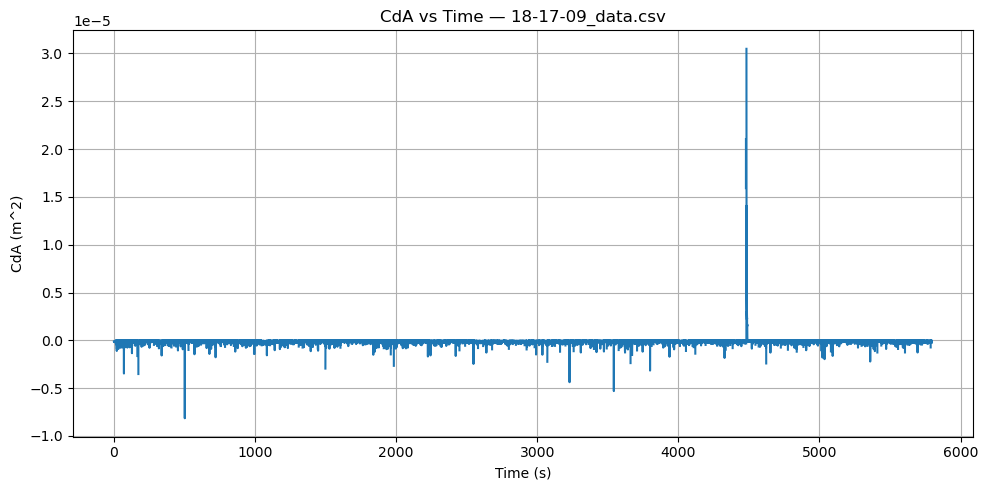

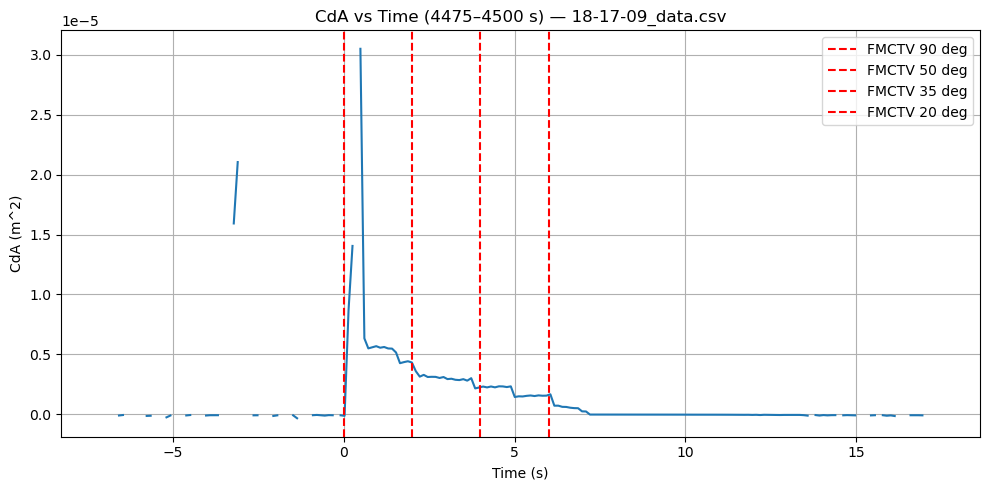



Combined results available in variable 'combined'


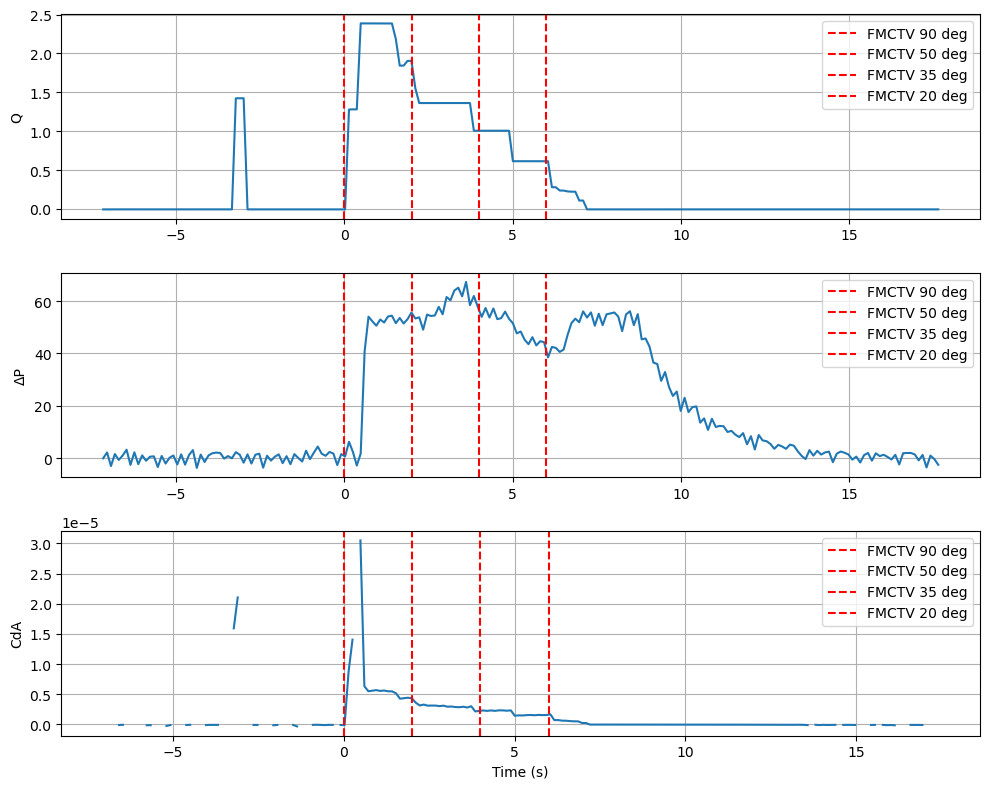

   Angle_deg  CdA_mean       CdA_std
0         90  0.000006  6.036738e-06
1         50  0.000004  5.105881e-07
2         35  0.000002  3.137345e-07
3         20  0.000001  4.112690e-07


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import correlate

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------
rho = 997.0
time_window = None

UPSTREAM_NAME = "FM-PT"
DOWNSTREAM_NAME = "FI-PT"
FLOW_NAME = "FM-FM"

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def load_sensor_csv(path: Path):
    df = pd.read_csv(path, header=0)
    df["t_rel"] = df.t_wall - df.t_wall.min()
    return df

def extract_sensor(df, sensor_name, time_window=None):
    g = df[df["sensor_name"].str.strip() == sensor_name].copy()
    if g.empty:
        raise ValueError(f"Sensor '{sensor_name}' not found.")
    g = g.sort_values("t_rel")
    t = g.t_rel.to_numpy()
    v = g.value.to_numpy()
    if time_window is not None:
        tmin, tmax = time_window
        mask = (t > tmin) & (t < tmax)
        t = t[mask]
        v = v[mask]
    return t, v

# ------------------------------------------------------------
# TOLERANCE-BASED DEDUPLICATION (robust)
# ------------------------------------------------------------
def clean_time_series(t, v, tol=1e-4):
    mask = ~np.isnan(t) & ~np.isnan(v)
    t = t[mask]
    v = v[mask]

    order = np.argsort(t)
    t = t[order]
    v = v[order]

    t_clean = [t[0]]
    v_clean = [v[0]]

    for i in range(1, len(t)):
        if abs(t[i] - t_clean[-1]) < tol:
            v_clean[-1] = 0.5 * (v_clean[-1] + v[i])
        else:
            t_clean.append(t[i])
            v_clean.append(v[i])

    return np.array(t_clean), np.array(v_clean)

# ------------------------------------------------------------
# CROSS-CORRELATION SHIFT
# ------------------------------------------------------------
def estimate_shift(t1, x1, t2, x2):
    t_min = max(t1.min(), t2.min())
    t_max = min(t1.max(), t2.max())
    if t_max <= t_min:
        return 0.0
    t_common = np.linspace(t_min, t_max, 5000)
    x1i = np.interp(t_common, t1, x1)
    x2i = np.interp(t_common, t2, x2)
    corr = correlate(x1i - x1i.mean(), x2i - x2i.mean(), mode='full')
    lag = np.arange(-len(x1i)+1, len(x1i))
    best_lag = lag[np.argmax(corr)]
    dt = t_common[1] - t_common[0]
    return best_lag * dt

# ------------------------------------------------------------
# CdA
# ------------------------------------------------------------
def compute_cda(P_up, P_down, Q, rho):
    dP = P_up - P_down          # Pa
    dP[dP <= 0] = np.nan
    mdot = rho * Q              # kg/s
    return mdot / np.sqrt(2 * rho * dP)  # m^2

# ------------------------------------------------------------
# MAIN PIPELINE
# ------------------------------------------------------------
def process_file(path: Path):
    print(f"\n--- Processing {path.name} ---")
    df = load_sensor_csv(path)

    # Extract raw
    t_up, P_up = extract_sensor(df, UPSTREAM_NAME, time_window)
    t_dn, P_dn = extract_sensor(df, DOWNSTREAM_NAME, time_window)
    t_fm_raw, Q_raw = extract_sensor(df, FLOW_NAME, time_window)

    # Clean with larger tolerance
    t_up, P_up = clean_time_series(t_up, P_up)
    t_dn, P_dn = clean_time_series(t_dn, P_dn)
    t_fm_raw, Q_raw = clean_time_series(t_fm_raw, Q_raw)

    print("Lengths after cleaning:", len(t_up), len(t_dn), len(t_fm_raw))

    # Pre-grid BEFORE computing dP
    t_min = max(t_up.min(), t_dn.min(), t_fm_raw.min())
    t_max = min(t_up.max(), t_dn.max(), t_fm_raw.max())
    t_pre = np.linspace(t_min, t_max, 20000)

    P_up_pre = np.interp(t_pre, t_up, P_up)
    P_dn_pre = np.interp(t_pre, t_dn, P_dn)
    Q_pre_raw = np.interp(t_pre, t_fm_raw, Q_raw)

    dP_pre = P_up_pre - P_dn_pre

    # Auto-shift FM-FM
    shift = estimate_shift(t_pre, Q_pre_raw, t_pre, dP_pre)
    print(f"Estimated FM-FM shift: {shift:.3f} s")

    # Apply shift
    t_fm_shifted = t_fm_raw - shift
    t_fm_shifted, Q_shifted = clean_time_series(t_fm_shifted, Q_raw)

    # Final common grid
    t_min = max(t_up.min(), t_dn.min(), t_fm_shifted.min())
    t_max = min(t_up.max(), t_dn.max(), t_fm_shifted.max())
    t_common = np.linspace(t_min, t_max, 50000)

    P_up_i = np.interp(t_common, t_up, P_up)
    P_dn_i = np.interp(t_common, t_dn, P_dn)
    Q_i    = np.interp(t_common, t_fm_shifted, Q_shifted)

    # After you have P_up_i, P_dn_i, Q_i on t_common

    # Convert units
    psi_to_Pa = 6894.757
    gpm_to_m3s = 0.003785411784 / 60.0

    P_up_SI = P_up_i * psi_to_Pa
    P_dn_SI = P_dn_i * psi_to_Pa
    Q_SI    = Q_i * gpm_to_m3s

    CdA = compute_cda(P_up_SI, P_dn_SI, Q_SI, rho)

    # Full plot
    plt.figure(figsize=(10,5))
    plt.plot(t_common, CdA)
    plt.xlabel("Time (s)")
    plt.ylabel("CdA (m^2)")
    plt.title(f"CdA vs Time — {path.name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Zoom 4475–4500
    plt.figure(figsize=(10,5))
    mask = (t_common >= 4475) & (t_common <= 4500)
    plt.plot(t_common[mask]-4482.25, CdA[mask])
    plt.axvline(x=0, color='red', linestyle='--', label='FMCTV 90 deg')
    plt.axvline(x=2, color='red', linestyle='--', label='FMCTV 50 deg')
    plt.axvline(x=4, color='red', linestyle='--', label='FMCTV 35 deg')
    plt.axvline(x=6, color='red', linestyle='--', label='FMCTV 20 deg')   
    plt.xlabel("Time (s)")
    plt.ylabel("CdA (m^2)")
    plt.title(f"CdA vs Time (4475–4500 s) — {path.name}")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()
    print()

    return pd.DataFrame({
        "time_s": t_common,
        "P_up": P_up_i,
        "P_down": P_dn_i,
        "Q_m3s": Q_i,
        "CdA": CdA
    })

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------
data_folder = Path(r"C:\my_stuff\Capstone\data_analysis\04")

csv_files = list(data_folder.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files.")

all_results = []
for f in csv_files:
    try:
        result = process_file(f)
        all_results.append(result)
    except Exception as e:
        print(f"Error processing {f.name}: {e}")

if all_results:
    combined = pd.concat(all_results, keys=[f.name for f in csv_files])
    print("\nCombined results available in variable 'combined'")

mask = (result["time_s"] >= 4475) & (result["time_s"] <= 4500)

t   = result["time_s"][mask]
Q   = result["Q_m3s"][mask]          # or Q_SI if you stored it
Pup = result["P_up"][mask]
Pdn = result["P_down"][mask]
CdA = result["CdA"][mask]

plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(t-4482.25, Q)
plt.axvline(x=0, color='red', linestyle='--', label='FMCTV 90 deg')
plt.axvline(x=2, color='red', linestyle='--', label='FMCTV 50 deg')
plt.axvline(x=4, color='red', linestyle='--', label='FMCTV 35 deg')
plt.axvline(x=6, color='red', linestyle='--', label='FMCTV 20 deg')   
plt.ylabel("Q")
plt.grid(True)
plt.legend()


plt.subplot(3,1,2)
plt.plot(t-4482.25, Pup - Pdn)
plt.axvline(x=0, color='red', linestyle='--', label='FMCTV 90 deg')
plt.axvline(x=2, color='red', linestyle='--', label='FMCTV 50 deg')
plt.axvline(x=4, color='red', linestyle='--', label='FMCTV 35 deg')
plt.axvline(x=6, color='red', linestyle='--', label='FMCTV 20 deg') 
plt.ylabel("ΔP")
plt.grid(True)
plt.legend()


plt.subplot(3,1,3)
plt.plot(t-4482.25, CdA)
plt.axvline(x=0, color='red', linestyle='--', label='FMCTV 90 deg')
plt.axvline(x=2, color='red', linestyle='--', label='FMCTV 50 deg')
plt.axvline(x=4, color='red', linestyle='--', label='FMCTV 35 deg')
plt.axvline(x=6, color='red', linestyle='--', label='FMCTV 20 deg') 
plt.ylabel("CdA")
plt.xlabel("Time (s)")
plt.grid(True)
plt.legend()


plt.tight_layout()
plt.show()



segments = {
    90: (4482.25 - 0.3, 4482.25 + 0.3),
    50: (4484.25 - 0.3, 4484.25 + 0.3),
    35: (4486.25 - 0.3, 4486.25 + 0.3),
    20: (4488.25 - 0.3, 4488.25 + 0.3),
}

cda_results = []

for angle, (t0, t1) in segments.items():
    mask = (result["time_s"] >= t0) & (result["time_s"] <= t1)
    CdA_mean = np.nanmean(result["CdA"][mask])
    CdA_std  = np.nanstd(result["CdA"][mask])
    cda_results.append((angle, CdA_mean, CdA_std))

df_cda = pd.DataFrame(cda_results, columns=["Angle_deg", "CdA_mean", "CdA_std"])
print(df_cda)

